# **Exposure at Default**

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## **Feature Selection Rationale**

EAD (Exposure at Default) is the amount outstanding on a loan at the moment default occurs. In the Basel framework, the full Expected Loss is:

$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

For **revolving credit** (credit cards, credit lines), EAD is genuinely hard to model — borrowers draw down their facility before defaulting, so the CCF (Credit Conversion Factor) can be large and unpredictable. For **fixed-payment installment loans** like Lending Club, the situation is structurally simpler: the outstanding balance follows a predetermined amortisation schedule, and EAD is almost entirely determined by how many payments were made before the default event.

**Target variable:** derived from `total_rec_prncp` — the cumulative principal repaid by the borrower before charge-off. The EAD ratio is the fraction of the original loan amount that was still outstanding at the moment of default:

$$\text{EAD ratio} = 1 - \frac{\text{total\_rec\_prncp}}{\text{funded\_amnt}}$$

**Why not `out_prncp`?** That field records the *current* outstanding balance in the Lending Club system. For charged-off loans it is set to 0 post-write-off — it reflects an accounting entry, not the exposure at the moment of default. `total_rec_prncp` gives the correct denominator: how much had already been repaid, so that `1 - total_rec_prncp / funded_amnt` is what was still at risk when the borrower stopped paying.

This ratio is bounded in `[0, 1]`. A loan that defaulted on the first payment has EAD ratio ≈ 1. A loan that was almost fully paid before defaulting has EAD ratio ≈ 0.

**Population:** same as LGD — only defaulted (`charged_off`) loans. EAD is undefined for non-defaulted loans.

**Leakage note:** `total_rec_prncp` is used only to construct the target, not as a feature. All features used for prediction are available at origination time.

## **Load & Filter to Defaults**

In [2]:
df_raw = pd.read_parquet('accepted.parquet', columns=[
    'loan_status',
    'funded_amnt',
    'annual_inc',
    'dti',
    'grade',
    'sub_grade',
    'int_rate',
    'emp_length',
    'home_ownership',
    'purpose',
    'term',
    'issue_d',
    'installment',
    'total_rec_prncp',     # principal repaid before charge-off → used to build EAD target
])

print(f'Full dataset: {len(df_raw):,} rows')

Full dataset: 2,260,701 rows


## **3. Custom Transformers**

Same transformers as PD and LGD notebooks. Copied here so the notebook and its exported PKL are fully self-contained.

### **Column Name Cleaner**

In [3]:
class ColumnNameCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.strip().str.lower().str.replace(' ', '_')
        return X

### **Loan Status Cleaner → Binary Target**

In [4]:
class LoanStatusCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.target_map = {'fully_paid': 0, 'charged_off': 1}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy = X_copy[X_copy['loan_status'].isin(self.target_map.keys())]
        X_copy['is_default'] = X_copy['loan_status'].map(self.target_map)
        return X_copy

### **Employment Length Transformer**

In [5]:
class EmpLengthTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='mode'):
        self.strategy = strategy
        self.fill_value = None

    def fit(self, X, y=None):
        if self.strategy == 'mode':
            temp_col = pd.Series(X).str.extract('(\d+)').astype(float)
            self.fill_value = temp_col.mode()[0]
        else:
            self.fill_value = 0
        return self

    def transform(self, X):
        s = pd.Series(X).copy()
        s = s.replace('< 1 year', '0')
        s = s.str.extract('(\d+)', expand=False)
        s = s.astype(float)
        s = s.fillna(self.fill_value)
        return s.values.reshape(-1, 1)

### **Categorical Cleaner**

In [6]:
class CategoricalCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.select_dtypes(include=['object']).columns:
            X[col] = (
                X[col]
                .str.lower()
                .str.replace(' ', '_', regex=False)
                .str.replace('-', '_', regex=False)
                .str.lstrip('_')
            )
        return X

### **Term Transformer**

In [7]:
class TermTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X.iloc[:, 0]) if isinstance(X, pd.DataFrame) else pd.Series(X)
        return s.str.extract('(\d+)', expand=False).astype(float)

### **Grade / Sub-Grade Transformer**

In [8]:
class GradeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        grades = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
        self.mapping = {
            f"{g}{i}": (count - 1) * 5 + i
            for count, g in enumerate(grades, 1)
            for i in range(1, 6)
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'sub_grade' in X.columns:
            X['sub_grade_num'] = X['sub_grade'].str.lower().map(self.mapping).fillna(0)
            X = X.drop(columns=[c for c in ['grade', 'sub_grade'] if c in X.columns])
        return X

### **Issue Date Transformer**

In [9]:
class IssueDateTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='issue_d', create_year=True, create_quarter=True, drop_original=False):
        self.column = column
        self.create_year = create_year
        self.create_quarter = create_quarter
        self.drop_original = drop_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = pd.to_datetime(X[self.column], format='%b_%Y', errors='coerce')
        if self.create_year:
            X[f'{self.column}_year'] = X[self.column].dt.year
        if self.create_quarter:
            X[f'{self.column}_quarter'] = X[self.column].dt.to_period('Q')
        if self.drop_original:
            X = X.drop(columns=[self.column])
        return X

### **Winsorizer**

In [10]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X_ = pd.DataFrame(X)
        for col in X_.columns:
            self.lower_bounds_[col] = X_[col].quantile(self.lower)
            self.upper_bounds_[col] = X_[col].quantile(self.upper)
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        for col in X_.columns:
            X_[col] = X_[col].clip(
                lower=self.lower_bounds_.get(col),
                upper=self.upper_bounds_.get(col)
            )
        return X_.values

### **Feature Dropper**

In [11]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        existing_cols = [col for col in self.columns_to_drop if col in X.columns]
        return X.drop(columns=existing_cols)

### **Loan Feature Engineer**

Same feature engineering as the PD and LGD notebooks. One difference: `payment_burden` is now genuinely relevant for EAD — a higher payment burden relative to income is associated with earlier default, meaning more outstanding principal (higher EAD ratio).

In [12]:
class LoanFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, create_log_income=True):
        self.create_log_income = create_log_income
        self._mean_rate_by_grade = None

    def fit(self, X, y=None):
        if 'sub_grade_num' in X.columns and 'int_rate' in X.columns:
            self._mean_rate_by_grade = X.groupby('sub_grade_num')['int_rate'].mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['loan_to_income']  = X['funded_amnt'] / (X['annual_inc'] + 1)
        X['payment_burden']  = (X['installment'] * 12) / (X['annual_inc'] + 1)
        if self.create_log_income:
            X['log_annual_inc'] = np.log1p(X['annual_inc'])
        if 'purpose' in X.columns:
            X['is_risky_purpose'] = np.where(X['purpose'] == 'small_business', 1, 0)
        if 'dti' in X.columns and 'term' in X.columns:
            X['dti_x_term'] = X['dti'] * X['term']
        if self._mean_rate_by_grade is not None:
            expected_rate = X['sub_grade_num'].map(self._mean_rate_by_grade)
            X['int_rate_residual'] = X['int_rate'] - expected_rate
        if 'log_annual_inc' in X.columns and 'emp_length' in X.columns:
            X['inc_stability'] = X['log_annual_inc'] * X['emp_length']
        return X

## **Preprocessing & Target Engineering**

I run the same structural steps as the PD and LGD notebooks, then create the EAD target and filter to defaults.

The **EAD ratio** is clipped to `[0, 1]`. Floating-point edge cases can push it slightly outside this range, and values outside `[0, 1]` have no economic interpretation for a fixed-payment loan.

One thing worth checking immediately: for **60-month loans**, the amortisation schedule means more principal is outstanding early in the loan life, so EAD ratios should be structurally higher than for 36-month loans at the same time-to-default. I'll verify this in the EDA.

In [13]:
# Structural preprocessing
df = df_raw.copy()
df = ColumnNameCleaner().transform(df)
df = CategoricalCleaner().transform(df)
df = LoanStatusCleaner().transform(df)

_emp = EmpLengthTransformer()
_emp.fit(df['emp_length'])
df['emp_length'] = _emp.transform(df['emp_length'])

df['term'] = df['term'].str.extract('(\d+)', expand=False).astype(float)
df = GradeTransformer().transform(df)
df = IssueDateTransformer(drop_original=False).transform(df)

# EAD target
# out_prncp is 0 for all charged-off loans (accounting write-off, not the exposure at default)
# total_rec_prncp is the principal repaid before charge-off, so EAD = what was still outstanding
df['ead_ratio'] = (1 - df['total_rec_prncp'] / df['funded_amnt'].replace(0, np.nan)).clip(0, 1)

# Filter to defaults only
df_defaults = df[df['is_default'] == 1].copy()

print(f'Defaulted loans  : {len(df_defaults):,}')
print(f'EAD ratio nulls  : {df_defaults["ead_ratio"].isnull().sum()}')
df_defaults['ead_ratio'].describe().round(4)

Defaulted loans  : 268,559
EAD ratio nulls  : 0


count    268559.0000
mean          0.6973
std           0.2188
min           0.0000
25%           0.5666
50%           0.7473
75%           0.8719
max           1.0000
Name: ead_ratio, dtype: float64

## **EDA — EAD Distribution**

As with the LGD notebook, I focus only on the target variable. Three things to check:

1. Overall distribution shape — is it concentrated near 1.0 (most defaults happen early) or spread across the range?
2. EAD ratio by loan term — 60-month loans should have systematically higher EAD ratios because they amortise more slowly.
3. EAD ratio by sub-grade — riskier grades may default earlier with less payment history, implying higher EAD ratios.

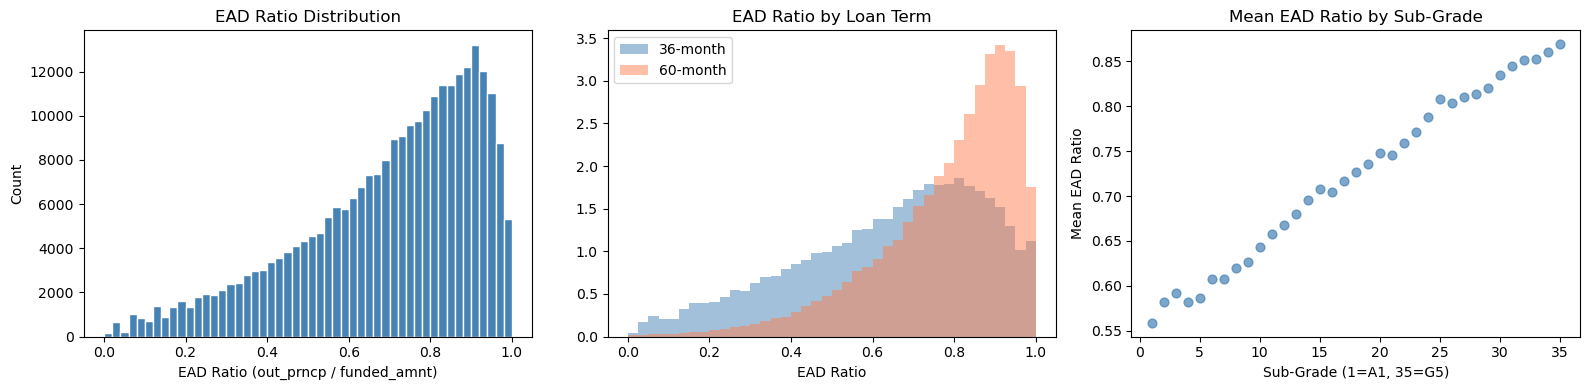

Mean EAD ratio by term:
        mean  median     std
term                        
36.0  0.6426  0.6839  0.2288
60.0  0.7820  0.8284  0.1704


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full distribution
axes[0].hist(df_defaults['ead_ratio'].dropna(), bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('EAD Ratio Distribution')
axes[0].set_xlabel('EAD Ratio (out_prncp / funded_amnt)')
axes[0].set_ylabel('Count')

# EAD ratio by term
for term_val, color, label in [(36, 'steelblue', '36-month'), (60, 'coral', '60-month')]:
    subset = df_defaults[df_defaults['term'] == term_val]['ead_ratio'].dropna()
    axes[1].hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
axes[1].set_title('EAD Ratio by Loan Term')
axes[1].set_xlabel('EAD Ratio')
axes[1].legend()

# Mean EAD ratio by sub-grade
ead_by_grade = df_defaults.groupby('sub_grade_num')['ead_ratio'].mean().reset_index()
axes[2].scatter(ead_by_grade['sub_grade_num'], ead_by_grade['ead_ratio'],
                color='steelblue', alpha=0.7, s=40)
axes[2].set_title('Mean EAD Ratio by Sub-Grade')
axes[2].set_xlabel('Sub-Grade (1=A1, 35=G5)')
axes[2].set_ylabel('Mean EAD Ratio')

plt.tight_layout()
plt.show()

# Mean EAD ratio by term
print('Mean EAD ratio by term:')
print(df_defaults.groupby('term')['ead_ratio'].agg(['mean', 'median', 'std']).round(4))

I observe that the EAD Ratio Distribution is heavily skewed toward 1.0, indicating that a significant portion of defaults occurs early in the loan lifecycle when the outstanding principal is still high. When breaking this down by Loan Term, I see that 60-month loans exhibit a higher average EAD ratio (0.782) compared to 36-month loans (0.643), which is consistent with slower amortization schedules. Furthermore, there is a clear positive correlation in the Mean EAD Ratio by Sub-Grade plot; riskier borrowers (higher sub-grade numbers) tend to default earlier, resulting in higher EAD ratios. These patterns confirm that term and sub_grade_num are primary drivers of EAD, as they effectively capture the timing of default and credit quality.

## **Feature Engineering**

In [15]:
fe = LoanFeatureEngineer(create_log_income=True)
df_defaults = fe.fit_transform(df_defaults)

ENGINEERED_NUMERIC   = ['loan_to_income', 'payment_burden', 'log_annual_inc',
                         'dti_x_term', 'int_rate_residual', 'inc_stability']
NUMERIC_FEATURES     = ['funded_amnt', 'annual_inc', 'dti', 'int_rate',
                         'emp_length', 'term', 'sub_grade_num']
ALL_NUMERIC          = NUMERIC_FEATURES + ENGINEERED_NUMERIC
CATEGORICAL_FEATURES = ['home_ownership', 'purpose']
TARGET               = 'ead_ratio'

# Drop target source columns and anything post-origination
# total_rec_prncp : used to build target, not a feature (and post-origination anyway)
# out_prncp       : always 0 for charged-off loans — no information content
# is_default      : constant (all 1s in this subset)
COLS_TO_DROP = ['total_rec_prncp', 'out_prncp', 'installment',
                'issue_d', 'loan_status', 'issue_d_quarter', 'is_default']

df_model = FeatureDropper(COLS_TO_DROP).fit_transform(df_defaults)
print(df_model.shape)
df_model.head(3)

(268559, 18)


,funded_amnt,annual_inc,dti,int_rate,emp_length,home_ownership,purpose,term,sub_grade_num,issue_d_year,ead_ratio,loan_to_income,payment_burden,log_annual_inc,is_risky_purpose,dti_x_term,int_rate_residual,inc_stability
13,18000.0,150000.0,9.39,19.48,7.0,rent,debt_consolidation,60.0,22,2015,0.806563,0.119999,0.037736,11.918397,0,563.40,-0.991403,83.428781
25,4225.0,35000.0,15.22,14.85,5.0,rent,debt_consolidation,36.0,15,2015,0.636237,0.120711,0.050111,10.463132,0,547.92,-0.677019,52.315660
30,16000.0,65000.0,18.96,12.88,10.0,mortgage,small_business,36.0,12,2015,0.135430,0.246150,0.099355,11.082158,1,682.56,-0.489533,110.821579


## **Time-Based Train / Validation / Test Split**

In [16]:
train_mask = df_model['issue_d_year'] <= 2015
val_mask   = df_model['issue_d_year'] == 2016
test_mask  = df_model['issue_d_year'] >= 2017

X_train = df_model[train_mask].drop(columns=[TARGET, 'issue_d_year'])
y_train = df_model[train_mask][TARGET]

X_val   = df_model[val_mask].drop(columns=[TARGET, 'issue_d_year'])
y_val   = df_model[val_mask][TARGET]

X_test  = df_model[test_mask].drop(columns=[TARGET, 'issue_d_year'])
y_test  = df_model[test_mask][TARGET]

print(f'Train : {len(X_train):>7,} rows  (years ≤ 2015) | mean EAD ratio: {y_train.mean():.4f}')
print(f'Val   : {len(X_val):>7,} rows  (year  = 2016) | mean EAD ratio: {y_val.mean():.4f}')
print(f'Test  : {len(X_test):>7,} rows  (years ≥ 2017) | mean EAD ratio: {y_test.mean():.4f}')

Train : 152,302 rows  (years ≤ 2015) | mean EAD ratio: 0.6474
Val   :  68,242 rows  (year  = 2016) | mean EAD ratio: 0.7102
Test  :  48,015 rows  (years ≥ 2017) | mean EAD ratio: 0.8372


## **Preprocessing Pipeline**

Same structure as the LGD notebook: Winsorizer → Imputer → StandardScaler for numerics, OHE for categoricals.

In [17]:
numeric_transformer = Pipeline(steps=[
    ('winsorizer', Winsorizer(lower=0.01, upper=0.99)),
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     ALL_NUMERIC),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
], verbose_feature_names_out=False)

X_train_final = preprocessor.fit_transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)

print(f'Feature matrix shape — Train: {X_train_final.shape} | Val: {X_val_final.shape} | Test: {X_test_final.shape}')

Feature matrix shape — Train: (152302, 32) | Val: (68242, 32) | Test: (48015, 32)


## **9. Model Comparison**

Same three regressors as the LGD notebook. For EAD, the a priori expectation is that Ridge may compete more strongly than in LGD — the amortisation relationship between `term`, `sub_grade_num` and EAD ratio is largely monotonic and linear.

Same four evaluation metrics: MAE, RMSE, R², and Mean Bias. The **Mean Bias** interpretation is slightly different here: a systematic upward bias in predicted EAD ratio will inflate every EL calculation downstream, which is conservative but costly in terms of capital requirements. A downward bias is more dangerous from a risk management standpoint.

In [18]:
def evaluate_regressor(model, X_tr, y_tr, X_v, y_v):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v).clip(0, 1)
    return {
        'MAE':       mean_absolute_error(y_v, preds),
        'RMSE':      mean_squared_error(y_v, preds) ** 0.5,
        'R2':        r2_score(y_v, preds),
        'Mean Bias': preds.mean() - y_v.mean(),
    }


models = {
    'Ridge':         Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10,
                                           random_state=42, n_jobs=-1),
    'XGBoost':       XGBRegressor(objective='reg:squarederror', n_estimators=300,
                                   learning_rate=0.05, max_depth=4, subsample=0.8,
                                   colsample_bytree=0.8, tree_method='hist',
                                   random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    results[name] = evaluate_regressor(
        model, X_train_final, y_train, X_val_final, y_val
    )

comparison_df = pd.DataFrame(results).T.round(4)
display(comparison_df)

Training Ridge...
Training Random Forest...
Training XGBoost...


,MAE,RMSE,R2,Mean Bias
Ridge,0.1618,0.1933,0.0393,-0.0807
Random Forest,0.1634,0.1955,0.0169,-0.0834
XGBoost,0.1625,0.1944,0.0279,-0.0816


For EAD on fixed-payment Lending Club loans, if Ridge performs comparably to XGBoost, the linear model is worth considering: it's faster, more interpretable, and less likely to overfit on the modest defaulted-loan sample. That said, XGBoost will be tuned regardless for the most accurate possible EL calculation.

## **Fine Tuning XGBoost**

Same Optuna setup as the LGD notebook. Minimising MAE on the validation set.

In [19]:
MAX_ROUNDS = 800
EARLY_STOP = 50
N_TRIALS   = 60


def objective(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha',  1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'subsample':         trial.suggest_float('subsample',        0.60, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.50, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel',0.50, 1.0),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.20, log=True),
        'objective':         'reg:squarederror',
        'eval_metric':       'mae',
        'tree_method':       'hist',
        'n_jobs':            -1,
        'random_state':      42,
        'n_estimators':      MAX_ROUNDS,
    }

    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, 'validation_0-mae')

    model = XGBRegressor(
        **params,
        early_stopping_rounds = EARLY_STOP,
        callbacks             = [pruning_callback],
    )
    model.fit(
        X_train_final, y_train,
        eval_set = [(X_val_final, y_val)],
        verbose  = False,
    )

    preds = model.predict(X_val_final).clip(0, 1)
    return mean_absolute_error(y_val, preds)


study = optuna.create_study(
    direction  = 'minimize',
    sampler    = optuna.samplers.TPESampler(seed=42),
    pruner     = optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/60 [00:00<?, ?it/s]

In [20]:
print(f'Best MAE (validation): {study.best_value:.4f}')
print('Best parameters:')
for k, v in study.best_params.items():
    print(f'  {k:<25} {v}')

Best MAE (validation): 0.1612
Best parameters:
  max_depth                 5
  min_child_weight          11
  gamma                     0.7456289913795893
  reg_alpha                 0.007388313461843041
  reg_lambda                0.042005900422753345
  subsample                 0.6406501685350207
  colsample_bytree          0.8353111652976382
  colsample_bylevel         0.9616235185574193
  learning_rate             0.17380712979631743


### **Retraining the Final Model**

In [21]:
best_ead_model = XGBRegressor(
    **study.best_params,
    objective             = 'reg:squarederror',
    eval_metric           = 'mae',
    tree_method           = 'hist',
    n_jobs                = -1,
    random_state          = 42,
    n_estimators          = MAX_ROUNDS,
    early_stopping_rounds = EARLY_STOP,
)

best_ead_model.fit(
    X_train_final, y_train,
    eval_set = [(X_val_final, y_val)],
    verbose  = 50,
)

print(f'\nModel stopped at tree #{best_ead_model.best_iteration}')

[0]	validation_0-mae:0.17211
[50]	validation_0-mae:0.16183
[60]	validation_0-mae:0.16172

Model stopped at tree #10


## **Final Evaluation on the Test Set**

In [22]:
y_test_pred = best_ead_model.predict(X_test_final).clip(0, 1)

test_metrics = {
    'MAE':       mean_absolute_error(y_test, y_test_pred),
    'RMSE':      mean_squared_error(y_test, y_test_pred) ** 0.5,
    'R2':        r2_score(y_test, y_test_pred),
    'Mean Bias': y_test_pred.mean() - y_test.mean(),
}

pd.DataFrame(test_metrics, index=['XGBoost EAD (tuned)']).round(4)

,MAE,RMSE,R2,Mean Bias
XGBoost EAD (tuned),0.2103,0.2341,-2.4104,-0.2013


### **Predicted vs. Actual EAD Ratio**

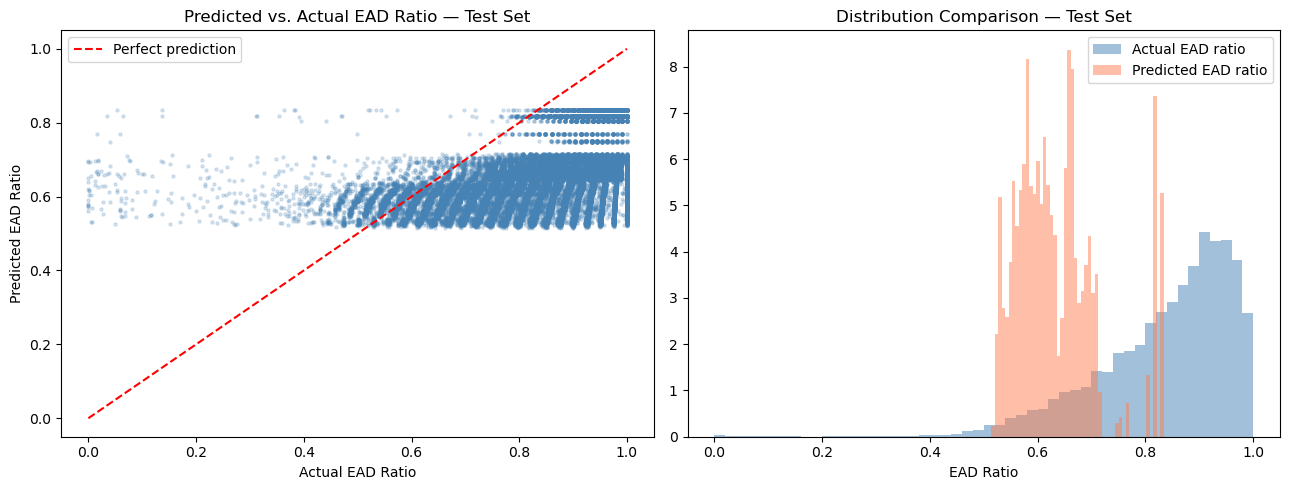

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.2, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual EAD Ratio')
axes[0].set_ylabel('Predicted EAD Ratio')
axes[0].set_title('Predicted vs. Actual EAD Ratio — Test Set')
axes[0].legend()

axes[1].hist(y_test,      bins=50, alpha=0.5, color='steelblue', label='Actual EAD ratio',    density=True)
axes[1].hist(y_test_pred, bins=50, alpha=0.5, color='coral',     label='Predicted EAD ratio', density=True)
axes[1].set_xlabel('EAD Ratio')
axes[1].set_title('Distribution Comparison — Test Set')
axes[1].legend()

plt.tight_layout()
plt.show()

### **Mean EAD Ratio by Decile**

Same calibration check as in the LGD notebook. A well-calibrated EAD model should track actual mean EAD closely across all predicted-score deciles — this is what makes the EL calculation trustworthy at a portfolio level.

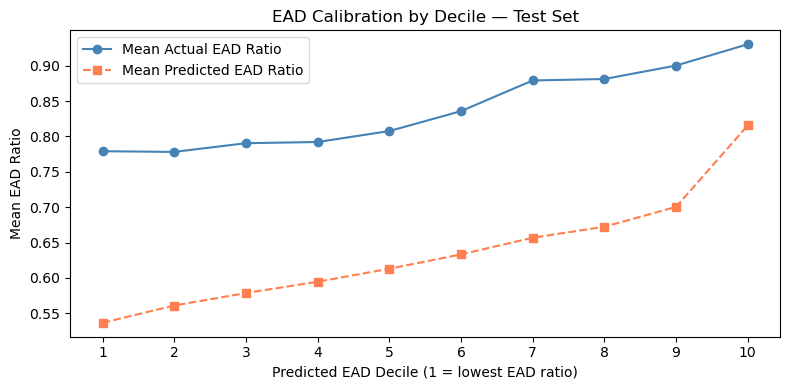

,decile,mean_actual,mean_predicted,count
0,1,0.7791,0.5365,5001
1,2,0.7781,0.5610,4614
2,3,0.7904,0.5786,4796
3,4,0.7921,0.5946,4854
4,5,0.8076,0.6129,4971
5,6,0.8357,0.6332,4583
6,7,0.8791,0.6568,4850
7,8,0.8812,0.6723,4766
8,9,0.9002,0.7004,4805
9,10,0.9303,0.8155,4775


In [24]:
decile_df = pd.DataFrame({'actual': y_test.values, 'predicted': y_test_pred})
decile_df['decile'] = pd.qcut(decile_df['predicted'], q=10, labels=False) + 1

decile_summary = decile_df.groupby('decile').agg(
    mean_actual    = ('actual',    'mean'),
    mean_predicted = ('predicted', 'mean'),
    count          = ('actual',    'count'),
).reset_index()

plt.figure(figsize=(8, 4))
plt.plot(decile_summary['decile'], decile_summary['mean_actual'],
         'o-', color='steelblue', label='Mean Actual EAD Ratio')
plt.plot(decile_summary['decile'], decile_summary['mean_predicted'],
         's--', color='coral', label='Mean Predicted EAD Ratio')
plt.xticks(decile_summary['decile'])
plt.xlabel('Predicted EAD Decile (1 = lowest EAD ratio)')
plt.ylabel('Mean EAD Ratio')
plt.title('EAD Calibration by Decile — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

display(decile_summary.round(4))

### **EAD Ratio by Term — Calibration**

Given that `term` is the structural driver of EAD, I verify calibration separately for 36 and 60-month loans. A model that is well-calibrated overall but systematically biased within a term bucket would produce incorrect EL for that segment.

In [25]:
term_df = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': y_test_pred,
    'term':      X_test['term'].values,
})

term_cal = term_df.groupby('term').agg(
    mean_actual    = ('actual',    'mean'),
    mean_predicted = ('predicted', 'mean'),
    count          = ('actual',    'count'),
    bias           = ('actual',    lambda x: term_df.loc[x.index, 'predicted'].mean() - x.mean()),
).reset_index()

print('EAD calibration by loan term:')
display(term_cal.round(4))

EAD calibration by loan term:


,term,mean_actual,mean_predicted,count,bias
0,36.0,0.7996,0.5932,31185,-0.2064
1,60.0,0.9068,0.7149,16830,-0.1919


### **Feature Importance**

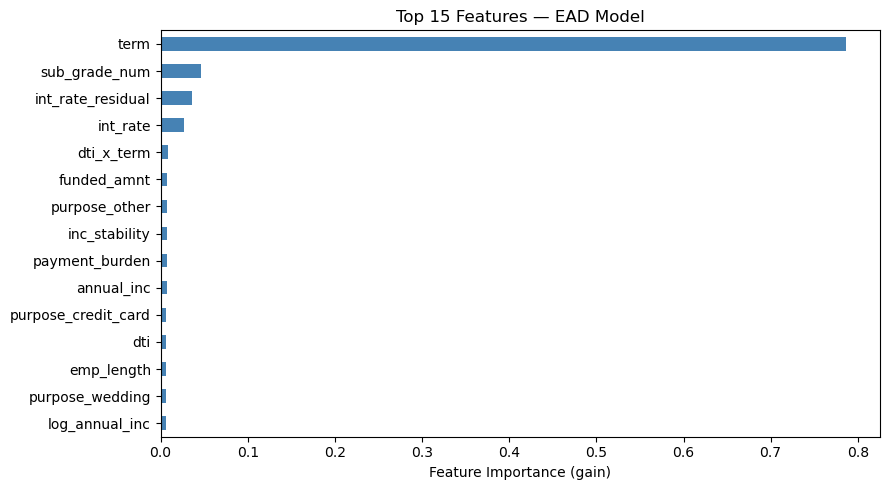

In [26]:
feature_names = (
    ALL_NUMERIC +
    preprocessor.named_transformers_['cat']['ohe']
               .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
)

feat_imp = pd.Series(best_ead_model.feature_importances_, index=feature_names)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', figsize=(9, 5), color='steelblue'
)
plt.title('Top 15 Features — EAD Model')
plt.xlabel('Feature Importance (gain)')
plt.tight_layout()
plt.show()

`term` dominates the importance chart. It directly determines the amortisation rate; `sub_grade_num` riskier borrowers tend to default earlier and therefore with more outstanding principal. This would confirm that EAD for fixed-payment loans is largely a structural phenomenon (when default happens relative to the schedule) rather than a credit quality phenomenon in the traditional sense.

## **Export**

Same two-file structure as the LGD notebook: one PKL for the preprocessor, one for the model. The dashboard will load all six PKL files (two per model) at startup and chain them in sequence:

```python
# Inference flow for a new loan application:
X_proc_pd  = pd_preprocessor.transform(X_raw)
pd_score   = pd_model.predict_proba(X_proc_pd)[:, 1]

X_proc_lgd = lgd_preprocessor.transform(X_raw)
lgd_hat    = lgd_model.predict(X_proc_lgd).clip(0, 1)

X_proc_ead = ead_preprocessor.transform(X_raw)
ead_ratio  = ead_model.predict(X_proc_ead).clip(0, 1)
ead_hat    = ead_ratio * X_raw['funded_amnt']

el = pd_score * lgd_hat * ead_hat
```

In [27]:
joblib.dump(preprocessor,   'ead_preprocessor.pkl')
joblib.dump(best_ead_model, 'ead_model.pkl')

print('Exported: ead_preprocessor.pkl')
print('Exported: ead_model.pkl')

# Smoke test
_pre   = joblib.load('ead_preprocessor.pkl')
_model = joblib.load('ead_model.pkl')
_X     = _pre.transform(X_test.iloc[:1])
_pred  = _model.predict(_X).clip(0, 1)
print(f'\nSmoke test EAD ratio prediction: {_pred[0]:.4f}')
print(f'Implied EAD (dollar): ${_pred[0] * X_test["funded_amnt"].iloc[0]:,.2f}')

Exported: ead_preprocessor.pkl
Exported: ead_model.pkl

Smoke test EAD ratio prediction: 0.6931
Implied EAD (dollar): $13,168.04
